# SVD - $W_O$ - TinyGPT2

## Introduction

As part of this notebook I wish explore the level of redundancy in the trained weights of my TinyGPT model. In particular, I am looking to apply a latent projection to the output weights matrix $W_O$.

In order to establish if there is any potiential behind this idea, the first goal is to examine the $W_O$ weight matrics across the different layers and examine if we can approximate $W_O$ using some form of factorisation method (SVD). This notebook documents the factorisation of the $W_O$ matrices from the GPT2 model.

## Notebook Setup

In [1]:
%%capture
! pip install transformers torch==2.2.2 numpy==1.26.4 safetensors matplotlib pandas

## Define the necessary libraries

In [2]:
# Base libraries
from safetensors import safe_open
import glob
from pathlib import Path
import hydra
from tqdm.notebook import tqdm

# Maths
import numpy as np
import torch
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Transformers
from transformers import GPT2LMHeadModel

# MLA
from mla.model_training.model_training import ModelPreTraining
from mla.models.GPT2.config import GPT2Config
from mla.models.GPT2.heads import GPT2LMHeadModel

/Users/davidquinlan/.pyenv/versions/3.13.14/envs/mla_res/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Load the TinyGPT2 Model

In [4]:
# Define the model path
parent = Path.cwd().parent
tiny_gpt2_model_path = parent / "training_models/TinyGPT2/pretraining/GPT2_h312_l6_a4_MHA_Skylion007__openwebtext_seq512_seed42.th"

In [5]:
# Define the TinyGPT2 model
model = ModelPreTraining.load_model(
    model_class=GPT2LMHeadModel,
    checkpoint_path=tiny_gpt2_model_path,
    config_class=GPT2Config,
)
_ = model.eval()

In [6]:
# Extract the WO weight matrices
W_outputs = []
for i, layer in enumerate(model.transformer.h):
    W_o = layer.attn.c_proj.weight.detach().cpu().numpy()
    W_outputs.append(W_o)

In [7]:
# Explore W
len(W_outputs)
W_outputs[0].shape

6

(312, 312)

## Apply SVD to each $W_O$ matrix

## Calculate the effective rank of each weight matrix

### Retension based rank (Energy Cutoff)

This is a threshold based matric, which focuses on the question, how many singular values do I need to preserve at least $x\%$ of the matrices total energy. This allows for the direct calculation of compressibility of a matrix.

In particular, in ML the singular value represents the stretch of each dimension, but S squared represents the energy (or variance) contained in that dimension.

In [8]:
def calculate_retension_based_rank(S, threshold_list):
    """
    This function take a matrices singular values and estimate the retension based rank for a list of thresholds.
    It essentially takes the singular values, squares them to represent each Wo dimensions variance and subsequently, calculates 
    the cumulative percentage energy values. Then taking the thresholds we find the number of dimensions that combine to cross the 
    pre-defined minimum thresholds.
    """

    # Calculate the cumulative percentage energy values -> Cumulative sum / total energy (S**2)
    cumulative_energy = np.cumsum(S**2) / np.sum(S**2)

    # Find smallest k such that cumulative energy >= alpha
    retention_based_rank_values = [{threshold: np.searchsorted(cumulative_energy, threshold) + 1} for threshold in threshold_list]

    return retention_based_rank_values

### Entropy based effective rank

Given singular values $S$ of a matrix $W$, we want to calculate the effective rank, such that:

- If the spectrum is uniform → rank is high
- If a few singular values dominate → rank is low
- If one singular value dominates → rank ≈ 1
- If all singular values are equal → rank = full rank

The entropy-based effective rank satisfies all of these.

In [9]:
def calculate_effective_rank(S):
    """
    Calculating the entropy based effective rank value. Remember that S**2 represents the energy of that dimension and thus we initially 
    calculate a energy based probability distribution which sums to 1. We then measure the uncertainty via the entropy calculation. We then
    convert back to a rank value by taking the exp.
    """

    # Calculate the energy based probability
    p = (S**2) / np.sum(S**2)

    # Calculate the Shannon entropy (log scale)
    H = -np.sum(p * np.log(p))
    
    # Calculate the effective rank (R scale)
    entropy_based_effective_rank = np.exp(H)

    return entropy_based_effective_rank

In [10]:
def calculate_SVD_rank_metrics(WO):
    """
    First calculate the SVD and then calculate the retension based rank value and entropy baesd effective rank values. 
    """

    # Create a list to store the results
    svd_layers = []
    
    # For each layers WO matrix
    for layer, wo in enumerate(WO):
    
        # Calculate the SVD
        U, S, VT = np.linalg.svd(wo, full_matrices=False)
    
        # Calculate the retension based rank values
        retension_based_rank_values = calculate_retension_based_rank(S, [0.99, 0.999])    
    
        # Calculate the entropy based effective rank
        entropy_based_effective_rank = calculate_effective_rank(S)
        
        # Store the results
        svd_layers.append({
            "layer": layer,
            "U": U,
            "S": S,
            "VT": VT,
            "retension_based_rank_values": retension_based_rank_values,
            "entropy_based_effective_rank": entropy_based_effective_rank,
        })

    return svd_layers

In [11]:
# Calculate the entropy based effective rank and also retention based rank values
svd_layers = calculate_SVD_rank_metrics(W_outputs)

In [12]:
# Convert to a dataframe
svd_layers_df = pd.DataFrame(svd_layers)

In [13]:
# Expand out the retensio based rank values
svd_layers_df_expanded = pd.concat([
    svd_layers_df.drop(columns='retension_based_rank_values'),
    svd_layers_df['retension_based_rank_values'].apply(lambda lst: {k: v for d in lst for k, v in d.items()}).apply(pd.Series)
], axis=1)

In [14]:
# Rename the columns
svd_layers_df_expanded = svd_layers_df_expanded.rename(columns={0.99: 'r99', 0.999: 'r99.9'})


## Plot the curves of the retension based rank values

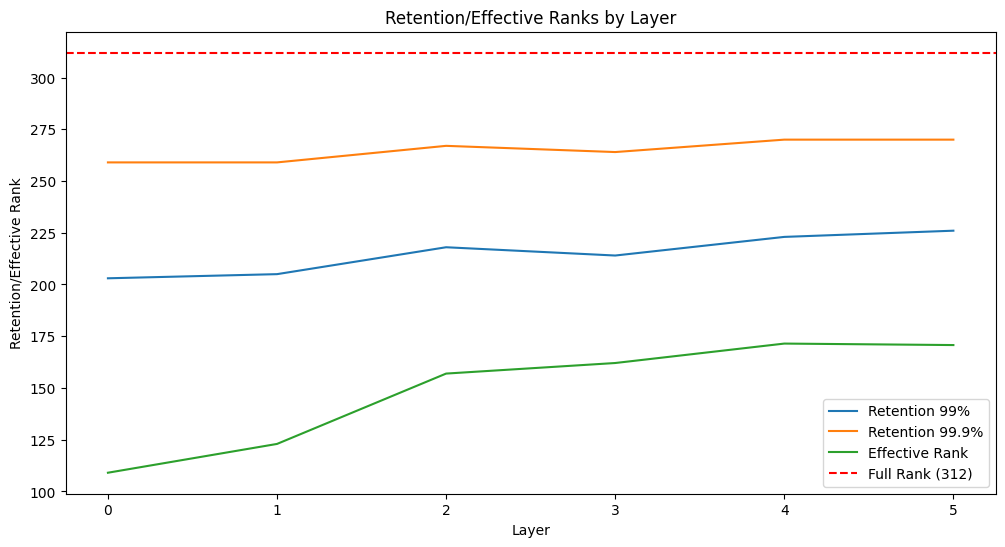

In [15]:
# Plot the  
ax = svd_layers_df_expanded.plot(x='layer', y=['r99', 'r99.9', 'entropy_based_effective_rank'], figsize=(12, 6))

# Add a custom horizontal line
_ = plt.axhline(y=W_outputs[0].shape[0], color='red', linestyle='--', label='Threshold Line')

# Add titles, labels and legend
_ = plt.ylabel('Retention/Effective Rank')
_ = plt.xlabel('Layer')
_ = plt.title('Retention/Effective Ranks by Layer')
_ = ax.legend(['Retention 99%', 'Retention 99.9%', "Effective Rank", f"Full Rank ({W_outputs[0].shape[0]})"])
plt.show()

## Calculate the average value across the different layers

In [16]:
# Calculate and print with 2-digit precision
print(f"Average Retention 99%: {svd_layers_df_expanded['r99'].mean():.2f}")
print(f"Average Retention 99.9%: {svd_layers_df_expanded['r99.9'].mean():.2f}")
print(f"Average Effective Rank (Entropy): {svd_layers_df_expanded['entropy_based_effective_rank'].mean():.2f}")

Average Retention 99%: 214.83
Average Retention 99.9%: 264.83
Average Effective Rank (Entropy): 148.87


## Conclusion
From this plot I can confirm that I believe the TinyGPT2 model with MHA that I trained appears to be moderately overparameterised in  the output projection matrix $W_O$. This would suggest that this compress/decompress technique should work.